In [14]:
import sklearn
import pandas
import numpy

In [15]:
import pandas as pd

df = pd.read_csv("../data/processed/preprocessed.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)
print("Target distribution:\n", df["habitable_binary"].value_counts())

Shape: (6100, 34)
Columns: Index(['planet_name', 'host_star_name', 'radius_earth', 'pl_radj',
       'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis',
       'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity',
       'star_metallicity', 'star_spectype', 'habitability_score',
       'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B',
       'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown',
       'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled',
       'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled',
       'star_temp_k_scaled', 'star_luminosity_scaled',
       'star_metallicity_scaled', 'habitable_binary'],
      dtype='object')
Target distribution:
 habitable_binary
0    6073
1      27
Name: count, dtype: int64


In [16]:
# Cell 1: imports & file path
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
INPUT_PATH = "../data/processed/preprocessed.csv"   # adjust if needed
OUT_DIR = "../data/processed/splits"               # where splits will be saved
os.makedirs(OUT_DIR, exist_ok=True)

print("Working dir:", os.getcwd())
print("Input file:", INPUT_PATH)

Working dir: c:\Users\shish\Desktop\B13-ExoHabitAI\notebooks
Input file: ../data/processed/preprocessed.csv


In [17]:
# Cell 2: load and inspect
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(f"Input file not found: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nPreview:")
display(df.head(3))

Loaded shape: (6100, 34)
Columns: ['planet_name', 'host_star_name', 'radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled', 'habitable_binary']

Preview:


,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,radius_earth_scaled,mass_earth_scaled,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary
0,11 Com b,11 Com,2.42,NaN,196.050555,NaN,323.21000,1.178,811.0,1.33,...,0.0,0.0,10.220065,5.369859,0.0,0.0,-0.768936,2.00510,-1.142857,0
1,11 UMi b,11 UMi,2.42,NaN,196.050555,NaN,516.21997,1.530,811.0,1.33,...,0.0,0.0,16.539934,7.129485,0.0,0.0,-1.491933,0.00000,0.000000,0
2,14 And b,14 And,2.42,NaN,196.050555,NaN,186.76000,0.775,811.0,1.33,...,0.0,0.0,5.752181,3.355287,0.0,0.0,-0.753623,1.86679,-0.904762,0


In [18]:
# Cell 3: drop identifiers / leakage (only if present)
# Add any column names you know are identifiers or leakage
id_cols = ["planet_name", "host_star_name", "host_star", "id"]        # common examples
leakage_cols = ["habitability_score", "habitability_index", "score"] # columns derived from target

# Build list of columns to drop that actually exist
to_drop = [c for c in (id_cols + leakage_cols) if c in df.columns]
if to_drop:
    print("Dropping these identifier/leakage columns (if present):", to_drop)
    df = df.drop(columns=to_drop)

# If your preprocessing created both raw and scaled versions, keep the raw OR scaled version
# The rule here: prefer scaled *_scaled columns for modeling (they are ready for ML).
scaled_cols = [c for c in df.columns if c.endswith("_scaled")]
# For any pair raw & scaled (e.g. radius, radius_scaled) drop the raw
raw_candidates = []
for sc in scaled_cols:
    raw = sc[:-7]  # remove "_scaled"
    if raw in df.columns:
        raw_candidates.append(raw)

if raw_candidates:
    print("Dropping raw columns in favour of scaled:", raw_candidates)
    df = df.drop(columns=raw_candidates)

print("Shape after cleanup:", df.shape)

Dropping these identifier/leakage columns (if present): ['planet_name', 'host_star_name', 'habitability_score']
Dropping raw columns in favour of scaled: ['radius_earth', 'mass_earth', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity']
Shape after cleanup: (6100, 22)


In [19]:
# Cell 4: specify target name and prepare y
TARGET = "habitable_binary"   # change if your column name differs

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' not found. Columns: {df.columns.tolist()}")

# Make sure target is numeric (0/1)
y = df[TARGET].copy()
if y.dtype == "object":
    # try converting to numeric (e.g., '0','1' or 'True','False')
    y = pd.to_numeric(y, errors='coerce')

if y.isnull().any():
    raise ValueError("Target contains NaN after conversion. Fix target before splitting.")

# Convert to integer 0/1 if possible
y = y.astype(int)
print("Target distribution (value counts):")
print(y.value_counts(dropna=False))

# create X by dropping target
X = df.drop(columns=[TARGET])
print("Feature set shape:", X.shape)

Target distribution (value counts):
habitable_binary
0    6073
1      27
Name: count, dtype: int64
Feature set shape: (6100, 21)


In [20]:
# Cell 5: optional - drop any remaining string/object columns that are identifiers or useless
# If you have categorical features you want to keep, skip this cell or tweak to only drop pure text IDs.

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
# If those are legitimate categorical features (star types), keep them. 
# Here we assume star type columns include 'star_A', 'star_B', 'star_G' one-hot; otherwise edit.
print("Object-type columns found in X:", object_cols)

# Example: if you have one-hot columns for star types (star_A...), they will be numeric.
# If any object columns are truly non-informative (names), drop them:
drop_object_cols = [c for c in object_cols if c.lower().startswith(("name", "id", "planet"))]
if drop_object_cols:
    print("Dropping object identifier columns:", drop_object_cols)
    X = X.drop(columns=drop_object_cols)

print("Shape after dropping object ids:", X.shape)

Object-type columns found in X: ['star_spectype']
Shape after dropping object ids: (6100, 21)


In [21]:
# Cell 6: train/test split
test_size = 0.20

# If there are at least 2 classes, stratify. Otherwise do a plain split and warn.
stratify_param = y if y.nunique() > 1 else None
if stratify_param is None:
    print("WARNING: target has only one class — cannot stratify. Check your target.")
else:
    print("Stratifying on target with class counts:", y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=stratify_param
)

print("Train shape X:", X_train.shape, "y:", y_train.shape)
print("Test  shape X:", X_test.shape, "y:", y_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=False))
print("\nTest  target distribution:\n", y_test.value_counts(normalize=False))

Stratifying on target with class counts: {0: 6073, 1: 27}
Train shape X: (4880, 21) y: (4880,)
Test  shape X: (1220, 21) y: (1220,)

Train target distribution:
 habitable_binary
0    4858
1      22
Name: count, dtype: int64

Test  target distribution:
 habitable_binary
0    1215
1       5
Name: count, dtype: int64


In [22]:
    # Cell 7: save splits
X_train.to_csv(os.path.join(OUT_DIR, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(OUT_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(OUT_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(OUT_DIR, "y_test.csv"), index=False)

print("Saved splits to:", OUT_DIR)
print(os.listdir(OUT_DIR))

Saved splits to: ../data/processed/splits
['baseline_results.csv', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


In [23]:
# Cell 8: quick load test (optional)
Xtr = pd.read_csv(os.path.join(OUT_DIR, "X_train.csv"))
ytr = pd.read_csv(os.path.join(OUT_DIR, "y_train.csv"))
print("Reload check:", Xtr.shape, ytr.shape)

Reload check: (4880, 21) (4880, 1)


In [24]:
# Cell A: imports and load splits
import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

RND = 42
SPLIT_DIR = "../data/processed/splits"   # change if different

# load
X_train = pd.read_csv(os.path.join(SPLIT_DIR, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(SPLIT_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(SPLIT_DIR, "y_train.csv"))
y_test  = pd.read_csv(os.path.join(SPLIT_DIR, "y_test.csv"))

# If y files saved as single-column dataframes, convert to 1d arrays/Series
if hasattr(y_train, "shape") and y_train.shape[1] > 1:
    y_train = y_train.iloc[:, 0]
else:
    y_train = y_train.squeeze()
if hasattr(y_test, "shape") and y_test.shape[1] > 1:
    y_test = y_test.iloc[:, 0]
else:
    y_test = y_test.squeeze()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(dropna=False))
print("y_test distribution:\n", y_test.value_counts(dropna=False))

X_train: (4880, 21) X_test: (1220, 21)
y_train distribution:
 habitable_binary
0    4858
1      22
Name: count, dtype: int64
y_test distribution:
 habitable_binary
0    1215
1       5
Name: count, dtype: int64


In [25]:
# Cell B: column detection & preprocessing pipeline
# Numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Detect columns already scaled (convention: end with "_scaled")
scaled_cols = [c for c in numeric_cols if c.endswith("_scaled")]
num_to_scale = [c for c in numeric_cols if c not in scaled_cols]

# Categorical (object or category)
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric cols:", len(numeric_cols), " (scale these):", len(num_to_scale))
print("Already scaled:", len(scaled_cols))
print("Categorical cols:", categorical_cols)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numeric pipeline
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_cols),
        ("cat", cat_transformer, categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessor rebuilt with imputation.")


Numeric cols: 13  (scale these): 4
Already scaled: 9
Categorical cols: ['star_spectype', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown']
Preprocessor rebuilt with imputation.


In [26]:
# Cell C: helper functions to report metrics
def evaluate_on_test(model, X_test, y_test):
    y_pred = model.predict(X_test)
    prob = None
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        try:
            prob = model.decision_function(X_test)
        except Exception:
            prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, prob) if prob is not None and len(np.unique(y_test)) > 1 else np.nan
    cm = confusion_matrix(y_test, y_pred)

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, roc_auc=roc, confusion=cm, y_pred=y_pred)

In [27]:
# Cell D: baseline models and CV config
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RND)

models = {
    "LogisticRegression": LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RND
),
    "DecisionTree_depth5": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RND)
}

# We'll wrap each model into a full pipeline with preprocessor
pipelines = {}
for name, clf in models.items():
    pipelines[name] = Pipeline([("pre", preprocessor), ("clf", clf)])
print("Pipelines prepared:", list(pipelines.keys()))

Pipelines prepared: ['LogisticRegression', 'DecisionTree_depth5']


In [28]:
# Cell E: cross-validate on training set and report mean ± std for key metrics
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}
cv_results = {}

for name, pipe in pipelines.items():
    print(f"\n--- CV for {name} ---")
    res = cross_validate(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=1,
    error_score="raise"
)
    summary = {metric: (np.mean(res[f"test_{metric}"]), np.std(res[f"test_{metric}"])) for metric in scoring}
    cv_results[name] = summary
    for metric, (mean, std) in summary.items():
        print(f"{metric}: {mean:.4f} ± {std:.4f}")


--- CV for LogisticRegression ---
accuracy: 0.9574 ± 0.0029
precision: 0.0817 ± 0.0127
recall: 0.8182 ± 0.0909
f1: 0.1485 ± 0.0225

--- CV for DecisionTree_depth5 ---
accuracy: 0.9994 ± 0.0002
precision: 1.0000 ± 0.0000
recall: 0.8636 ± 0.0455
f1: 0.9262 ± 0.0262


In [29]:
print("Missing values in X_train:", X_train.isnull().sum().sum())

Missing values in X_train: 4559


In [30]:
# Cell F: fit on full train, evaluate on test
final_results = []
for name, pipe in pipelines.items():
    print(f"\n>>> Training {name} on full training set")
    pipe.fit(X_train, y_train)
    ev = evaluate_on_test(pipe, X_test, y_test)
    cm = ev.pop("confusion")
    print("Test metrics:")
    print(f"Accuracy:  {ev['accuracy']:.4f}")
    print(f"Precision: {ev['precision']:.4f}")
    print(f"Recall:    {ev['recall']:.4f}")
    print(f"F1:        {ev['f1']:.4f}")
    print(f"ROC AUC:   {ev['roc_auc'] if not np.isnan(ev['roc_auc']) else 'N/A'}")
    print("Confusion matrix:\n", cm)
    print("\nClassification report (test):")
    print(classification_report(y_test, ev['y_pred'], zero_division=0))
    row = {"model": name, **{k: ev[k] for k in ("accuracy","precision","recall","f1","roc_auc")}}
    final_results.append(row)

# Save summary CSV
pd.DataFrame(final_results).to_csv(os.path.join(SPLIT_DIR, "baseline_results.csv"), index=False)
print("\nSaved baseline results to:", os.path.join(SPLIT_DIR, "baseline_results.csv"))


>>> Training LogisticRegression on full training set
Test metrics:
Accuracy:  0.9689
Precision: 0.1163
Recall:    1.0000
F1:        0.2083
ROC AUC:   0.9865020576131687
Confusion matrix:
 [[1177   38]
 [   0    5]]

Classification report (test):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1215
           1       0.12      1.00      0.21         5

    accuracy                           0.97      1220
   macro avg       0.56      0.98      0.60      1220
weighted avg       1.00      0.97      0.98      1220


>>> Training DecisionTree_depth5 on full training set
Test metrics:
Accuracy:  0.9984
Precision: 0.7143
Recall:    1.0000
F1:        0.8333
ROC AUC:   0.9991769547325102
Confusion matrix:
 [[1213    2]
 [   0    5]]

Classification report (test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       0.71      1.00      0.83         5

    accuracy  

In [31]:
# Cell 1 — Imports & load
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Path to your preprocessed csv (adjust if different)
DATA_PATH = "../data/processed/preprocessed.csv"   # <- change if needed

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Target distribution:\n", df["habitable_binary"].value_counts(dropna=False))

Loaded: ../data/processed/preprocessed.csv
Shape: (6100, 34)
Target distribution:
 habitable_binary
0    6073
1      27
Name: count, dtype: int64


In [32]:
# Cell 2 — Prepare X and y, train-test split
# Drop identifier columns (if present) and the target
id_cols = [c for c in ["planet_name", "host_star_name"] if c in df.columns]
target_col = "habitable_binary"

X = df.drop(columns=id_cols + [target_col], errors="ignore")
y = df[target_col].astype(int)

# Quick sanity
print("Feature columns:", X.columns.tolist()[:20])
print("Numeric / object counts:", X.select_dtypes(include=[np.number]).shape[1], "/", X.select_dtypes(include=["object","category"]).shape[1])

# Train-test split (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Feature columns: ['radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K']
Numeric / object counts: 23 / 1
Train: (4880, 31) Test: (1220, 31)


In [33]:
# Cell 3 — Preprocessor (numeric impute+scale, categorical impute+OHE)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings("ignore", category=DataConversionWarning)

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
], remainder="drop")  # drop other columns if any

print("Numeric cols:", len(numeric_cols), numeric_cols)
print("Categorical cols:", len(categorical_cols), categorical_cols)

Numeric cols: 23 ['radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled']
Categorical cols: 1 ['star_spectype']


In [34]:
# Cell 4 — Build pipelines for RandomForest and XGBoost
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except Exception:
    raise ImportError("Install xgboost: pip install xgboost")

# For class imbalance: compute scale_pos_weight for XGBoost
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / (pos + 1e-9)
print(f"Train positive/negative: {pos}/{neg}  scale_pos_weight={scale_pos_weight:.2f}")

rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",  # balances classes
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

pipelines = {
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe
}

Train positive/negative: 22/4858  scale_pos_weight=220.82


In [35]:
!pip install xgboost

In [36]:
# Cell 5 — Cross-validate pipelines on training data
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in pipelines.items():
    print("\n--- CV for", name, "---")
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1, error_score="raise")
    summary = {metric: (np.mean(res[f"test_{metric}"]), np.std(res[f"test_{metric}"])) for metric in scoring}
    cv_results[name] = summary
    for metric, (mean, std) in summary.items():
        print(f"{metric}: {mean:.4f} ± {std:.4f}")


--- CV for RandomForest ---
accuracy: 0.9982 ± 0.0010
precision: 0.9500 ± 0.1000
recall: 0.6300 ± 0.2015
f1: 0.7340 ± 0.1846

--- CV for XGBoost ---
accuracy: 0.9990 ± 0.0009
precision: 0.8700 ± 0.1077
recall: 0.9100 ± 0.1114
f1: 0.8878 ± 0.1019


In [37]:
# Cell 6 — Fit pipelines on whole training set

import os
os.makedirs("models", exist_ok=True)

for name, pipe in pipelines.items():
    print("Fitting", name)
    pipe.fit(X_train, y_train)
    # Save fitted pipeline quickly (optional)
    joblib.dump(pipe, f"models/{name}_pipeline.joblib", compress=3)
    print("Saved models/{0}_pipeline.joblib".format(name))

Fitting RandomForest
Saved models/RandomForest_pipeline.joblib
Fitting XGBoost


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:24:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved models/XGBoost_pipeline.joblib


In [38]:
# Cell 7 — Evaluate on X_test
from sklearn.metrics import roc_auc_score

for name, pipe in pipelines.items():
    print("\n=== Test evaluation:", name, "===")
    y_pred = pipe.predict(X_test)
    # Probabilities for ROC AUC (if available)
    try:
        y_proba = pipe.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        y_proba = None
        auc = None

    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    if auc is not None:
        print("ROC AUC:", auc)


=== Test evaluation: RandomForest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      0.20      0.33         5

    accuracy                           1.00      1220
   macro avg       1.00      0.60      0.67      1220
weighted avg       1.00      1.00      1.00      1220

Confusion matrix:
 [[1215    0]
 [   4    1]]
ROC AUC: 0.9996707818930042

=== Test evaluation: XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      1.00      1.00         5

    accuracy                           1.00      1220
   macro avg       1.00      1.00      1.00      1220
weighted avg       1.00      1.00      1.00      1220

Confusion matrix:
 [[1215    0]
 [   0    5]]
ROC AUC: 1.0


In [39]:
# Cell 8 — Extract feature names from preprocessor and show importances
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []
    # numeric
    if hasattr(preprocessor, "transformers_"):
        for name, trans, cols in preprocessor.transformers_:
            if name == "num":
                feature_names += list(cols)
            elif name == "cat":
                # get categories from fitted OHE
                ohe = trans.named_steps["ohe"]
                ohe_names = ohe.get_feature_names_out(cols)
                feature_names += list(ohe_names)
    return feature_names

feat_names = get_feature_names_from_preprocessor(preprocessor)

for name, pipe in pipelines.items():
    print("\nFeature importances for", name)
    try:
        model = pipe.named_steps["clf"]
        importances = model.feature_importances_
        df_imp = pd.DataFrame({"feature": feat_names, "importance": importances})
        df_imp = df_imp.sort_values("importance", ascending=False).head(20)
        print(df_imp.to_string(index=False))
    except Exception as e:
        print("Couldn't extract importances for", name, ":", e)


Feature importances for RandomForest
                feature  importance
              eq_temp_k    0.158818
     habitability_score    0.122069
       eq_temp_k_scaled    0.121884
    radius_earth_scaled    0.095697
           radius_earth    0.084592
     star_temp_k_scaled    0.081119
            star_temp_k    0.079284
                pl_radj    0.068213
      orbital_stability    0.023875
       star_metallicity    0.020629
star_metallicity_scaled    0.019209
         orbital_period    0.017670
  semimajor_axis_scaled    0.015201
 star_luminosity_scaled    0.014433
         semimajor_axis    0.014426
  orbital_period_scaled    0.011996
      mass_earth_scaled    0.010689
        star_luminosity    0.007764
             mass_earth    0.006671
  stellar_compatibility    0.006007

Feature importances for XGBoost
             feature  importance
  habitability_score    0.960030
           eq_temp_k    0.021707
        radius_earth    0.013520
    star_metallicity    0.003449
      or

In [40]:
# Cell 9 — Save best pipeline manually (example: choose XGBoost)
best = "XGBoost"   # change to the name that performed best
os.makedirs("models", exist_ok=True)
joblib.dump(pipelines[best], f"models/{best}_final.joblib", compress=3)
print("Saved models/" + best + "_final.joblib")

Saved models/XGBoost_final.joblib


In [41]:
# Cell 1 - imports & load
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# models
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_hist_gradient_boosting  # noqa (if using HistGB fallback)
from sklearn.ensemble import HistGradientBoostingClassifier

# optional: xgboost (we'll try to import later)
print("pandas:", pd.__version__)

pandas: 2.2.2


c:\Users\shish\anaconda3\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [42]:
# Cell 2 - load cleaned CSV and split into X, y
df = pd.read_csv("../data/processed/preprocessed.csv")   # adjust path if needed
print("Loaded shape:", df.shape)

# choose target column name used in your preprocessing
TARGET = "habitable_binary"   # update if different

# option: drop identifier columns that are not features
drop_cols = ["planet_name", "host_star_name"]  # adjust to what you have
X = df.drop(columns=[TARGET] + [c for c in drop_cols if c in df.columns])
y = df[TARGET].astype(int)

# simple train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    stratify=y, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Loaded shape: (6100, 34)
Train shape: (4880, 31) Test shape: (1220, 31)


In [43]:
# Cell 3 - create preprocessor factory
def make_preprocessor(X_df, scaler="none"):
    # detect numeric and categorical columns
    numeric_cols = X_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
    categorical_cols = X_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # numeric pipeline: impute (median) then optionally scale
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scaler == "standard":
        num_steps.append(("scaler", StandardScaler()))
    elif scaler == "minmax":
        num_steps.append(("scaler", MinMaxScaler()))
    # else scaler == "none" -> no scaler (only imputer)
    from sklearn.pipeline import Pipeline as SKPipeline
    numeric_transformer = SKPipeline(num_steps)

    # categorical pipeline: impute (most_frequent) then one-hot encode
    cat_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
    categorical_transformer = SKPipeline(cat_steps)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",  # drop any other columns
        sparse_threshold=0
    )
    print(f"Preprocessor built. Numeric cols: {len(numeric_cols)}, Categorical cols: {len(categorical_cols)}")
    return preprocessor, numeric_cols, categorical_cols

# Example: build a preprocessor for tree models (no scaling)
preprocessor_tree, num_cols, cat_cols = make_preprocessor(X_train, scaler="none")

Preprocessor built. Numeric cols: 23, Categorical cols: 8


In [44]:
# Cell 4 - pipelines (RF + XGBoost fallback)
# compute scale_pos_weight for XGBoost if used
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / (pos + 1e-9)
print("pos/neg:", pos, "/", neg, "scale_pos_weight:", scale_pos_weight)

# Preprocessors: no scale for tree models (fast)
preprocessor_tree, _, _ = make_preprocessor(X_train, scaler="none")

# RandomForest pipeline
rf_pipe = Pipeline([
    ("pre", preprocessor_tree),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1))
])

# Try to import XGBoost; fallback to HistGradientBoosting if not installed
try:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([
        ("pre", preprocessor_tree),
        ("clf", XGBClassifier(
            n_estimators=200,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])
    print("XGBoost available -> using XGBClassifier")
except Exception as e:
    print("xgboost not available; using HistGradientBoostingClassifier as fallback. Error:", e)
    xgb_pipe = Pipeline([
        ("pre", preprocessor_tree),
        ("clf", HistGradientBoostingClassifier(random_state=42))
    ])

pipelines = {"RandomForest": rf_pipe, "XGB_or_HistGB": xgb_pipe}

pos/neg: 22 / 4858 scale_pos_weight: 220.81818180814463
Preprocessor built. Numeric cols: 23, Categorical cols: 8
XGBoost available -> using XGBClassifier


In [45]:
# Cell 5 - fit pipelines
for name, pipe in pipelines.items():
    print(f"\nFitting {name} ...")
    pipe.fit(X_train, y_train)
    print(f"{name} fitted.")


Fitting RandomForest ...
RandomForest fitted.

Fitting XGB_or_HistGB ...


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:24:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB_or_HistGB fitted.


In [46]:
# Cell 6 - quick evaluation on test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

for name, pipe in pipelines.items():
    print(f"\n=== {name} ===")
    y_pred = pipe.predict(X_test)
    try:
        y_proba = pipe.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_proba)
        print("ROC AUC:", auc)
    except Exception:
        print("predict_proba not available for this pipeline/model.")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


=== RandomForest ===
ROC AUC: 0.9998353909465021
              precision    recall  f1-score   support

           0     0.9959    1.0000    0.9979      1215
           1     0.0000    0.0000    0.0000         5

    accuracy                         0.9959      1220
   macro avg     0.4980    0.5000    0.4990      1220
weighted avg     0.9918    0.9959    0.9939      1220

Confusion matrix:
 [[1215    0]
 [   5    0]]

=== XGB_or_HistGB ===
ROC AUC: 1.0
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1215
           1     1.0000    1.0000    1.0000         5

    accuracy                         1.0000      1220
   macro avg     1.0000    1.0000    1.0000      1220
weighted avg     1.0000    1.0000    1.0000      1220

Confusion matrix:
 [[1215    0]
 [   0    5]]


c:\Users\shish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
# Cell 7 - save the final pipeline (pick name)
import joblib, os
os.makedirs("models", exist_ok=True)

final_name = "RandomForest"   # choose best model name e.g. "RandomForest" or "XGB_or_HistGB"
joblib.dump(pipelines[final_name], f"models/{final_name}_pipeline.joblib", compress=3)
print("Saved:", f"models/{final_name}_pipeline.joblib")

Saved: models/RandomForest_pipeline.joblib


In [48]:
# Cell A - imports and quick checks
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier   # fallback if xgboost missing

# if you plan to use XGBoost uncomment later or install it
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

print("xgboost available:", xgb_available)

xgboost available: True


In [49]:
# Cell B - check preprocessor coverage & NaNs
# preprocessor should be the ColumnTransformer you built earlier and X_train the train set
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
# Get numeric/categorical lists if you stored them earlier in make_preprocessor
try:
    num_cols = num_cols  # from make_preprocessor earlier
    cat_cols = cat_cols
except Exception:
    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

covered = set(num_cols + cat_cols)
missing_cols = [c for c in X_train.columns if c not in covered]
print("Num cols detected:", len(num_cols), "Cat cols detected:", len(cat_cols))
print("Columns not covered by preprocessor (should be empty):", missing_cols)

# Check if X_train still contains NaNs (should not if preprocessor imputes)
nan_cols = X_train.columns[X_train.isnull().any()].tolist()
print("Columns in X_train with NaNs (before pipeline):", nan_cols)
if nan_cols:
    print("If any columns appear above, either they are not included in preprocessor or they have dtype mismatches.")

X_train shape: (4880, 31)
y_train shape: (4880,)
Num cols detected: 23 Cat cols detected: 8
Columns not covered by preprocessor (should be empty): []
Columns in X_train with NaNs (before pipeline): ['pl_radj', 'pl_massj']
If any columns appear above, either they are not included in preprocessor or they have dtype mismatches.


In [50]:
# Cell C - build pipelines for training
from sklearn.pipeline import Pipeline

# Ensure we have a preprocessor object built earlier (preprocessor_tree)
# If not, re-create: preprocessor_tree, num_cols, cat_cols = make_preprocessor(X_train, scaler="none")
prepro = preprocessor_tree  # use the tree preprocessor (no scaling)

# RandomForest pipeline
rf_pipe = Pipeline([
    ("pre", prepro),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   random_state=42, n_jobs=-1))
])

# XGBoost or fallback pipeline
if xgb_available:
    xgb_pipe = Pipeline([
        ("pre", prepro),
        ("clf", XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="logloss",
                              random_state=42, n_jobs=-1, scale_pos_weight=(y_train==0).sum()/( (y_train==1).sum()+1e-9)))
    ])
    xgb_name = "xgboost"
else:
    print("xgboost not found; using HistGradientBoostingClassifier as fallback")
    xgb_pipe = Pipeline([
        ("pre", prepro),
        ("clf", HistGradientBoostingClassifier(random_state=42))
    ])
    xgb_name = "xgboost_fallback"

pipelines = {"random_forest": rf_pipe, xgb_name: xgb_pipe}
print("Pipelines ready:", list(pipelines.keys()))

Pipelines ready: ['random_forest', 'xgboost']


In [51]:
# Cell D - fit and time each model
import time
os.makedirs("models", exist_ok=True)   # avoid FileNotFound error when saving

trained_models = {}
for name, pipe in pipelines.items():
    print(f"\nFitting {name} ...")
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()
    print(f"Fitted {name} in {t1-t0:.1f}s")
    trained_models[name] = pipe


Fitting random_forest ...
Fitted random_forest in 0.6s

Fitting xgboost ...


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:24:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitted xgboost in 0.4s


In [52]:
# Cell E - save pipelines to disk (requested filenames)
for name, pipe in trained_models.items():
    # map the internal name to the desired file name:
    if name == "random_forest":
        filename = "models/random_forest.pkl"
    elif name == "xgboost":
        filename = "models/xgboost.pkl"
    elif name == "xgboost_fallback":
        filename = "models/xgboost_fallback.pkl"
    else:
        filename = f"models/{name}.pkl"

    joblib.dump(pipe, filename, compress=3)
    print("Saved:", filename)

# optional: if you want a guaranteed 'models/xgboost.pkl' file even when xgboost missing:
if not xgb_available:
    joblib.dump(trained_models.get("xgboost_fallback"), "models/xgboost.pkl", compress=3)
    print("Saved fallback as models/xgboost.pkl (note: this is HistGradientBoosting fallback)")

Saved: models/random_forest.pkl
Saved: models/xgboost.pkl


In [53]:
# Cell F - load and smoke-test
m_rf = joblib.load("models/random_forest.pkl")
print("Loaded RF pipeline; predict sample:", m_rf.predict(X_test.iloc[:3]).tolist())

# XGBoost file (may be fallback)
m_xgb = joblib.load("models/xgboost.pkl")
print("Loaded XGB pipeline (or fallback); predict sample:", m_xgb.predict(X_test.iloc[:3]).tolist())

Loaded RF pipeline; predict sample: [0, 0, 0]
Loaded XGB pipeline (or fallback); predict sample: [0, 0, 0]


In [54]:
    # Cell 1 - imports and results folder
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay)

os.makedirs("results", exist_ok=True)
print("Results folder: results/")

Results folder: results/


In [55]:
# Cell 2 - evaluation helper
def evaluate_model(name, model, X_test, y_test, save_plots=True):
    """
    Evaluate a trained pipeline (preprocessor + classifier).
    - name: string identifier
    - model: fitted pipeline with .predict and normally .predict_proba or decision_function
    - X_test, y_test: test set (X can be raw features; pipeline will transform)
    Returns: dict of metrics
    """
    print(f"\n=== Evaluating: {name} ===")
    # Predictions
    y_pred = model.predict(X_test)
    # Probabilities / decision scores for ROC/AUC
    y_score = None
    try:
        # many classifiers have predict_proba
        y_score = model.predict_proba(X_test)[:, 1]
    except Exception:
        try:
            # some have decision_function
            y_score = model.decision_function(X_test)
            # decision_function might return shape (n_samples,) or (n_samples, n_classes)
            if y_score.ndim > 1:
                # pick the positive class scores if multi-output
                y_score = y_score[:, 1]
        except Exception:
            y_score = None

    # Compute base metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC (only if we have scores and both classes present)
    auc = None
    try:
        if y_score is not None and len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_score)
    except Exception as e:
        print("Could not compute ROC-AUC:", e)
        auc = None

    # Print classification report
    print("Classification report:")
    crep = classification_report(y_test, y_pred, digits=4, zero_division=0)
    print(crep)

    # Save classification report as txt + csv (dict)
    rep_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    with open(f"results/classification_report_{name}.txt", "w") as f:
        f.write(crep)
    pd.DataFrame(rep_dict).transpose().to_csv(f"results/classification_report_{name}.csv")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig_cm, ax_cm = plt.subplots(figsize=(4,4))
    disp.plot(ax=ax_cm, values_format='d', cmap='Blues')
    ax_cm.set_title(f"Confusion matrix - {name}")
    if save_plots:
        fig_cm.savefig(f"results/confusion_{name}.png", bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig_cm)

    # ROC curve plot (if possible)
    if y_score is not None and len(np.unique(y_test)) > 1:
        fpr, tpr, thr = roc_curve(y_test, y_score)
        fig_roc, ax_roc = plt.subplots(figsize=(5,4))
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name=name).plot(ax=ax_roc)
        ax_roc.plot([0,1],[0,1],"k--", linewidth=0.7)
        ax_roc.set_title(f"ROC curve - {name} (AUC={auc:.4f})" if auc is not None else f"ROC curve - {name}")
        if save_plots:
            fig_roc.savefig(f"results/roc_{name}.png", bbox_inches='tight', dpi=150)
        plt.show()
        plt.close(fig_roc)
    else:
        print("ROC curve skipped (no score available or single-class in y_test).")

    # return metric dict
    metrics = {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc if auc is not None else np.nan,
        "n_test": len(y_test)
    }
    return metrics

Models to evaluate: ['random_forest', 'xgboost']

=== Evaluating: random_forest ===
Classification report:
              precision    recall  f1-score   support

           0     0.9959    1.0000    0.9979      1215
           1     0.0000    0.0000    0.0000         5

    accuracy                         0.9959      1220
   macro avg     0.4980    0.5000    0.4990      1220
weighted avg     0.9918    0.9959    0.9939      1220



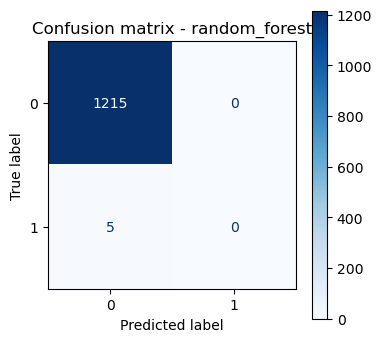

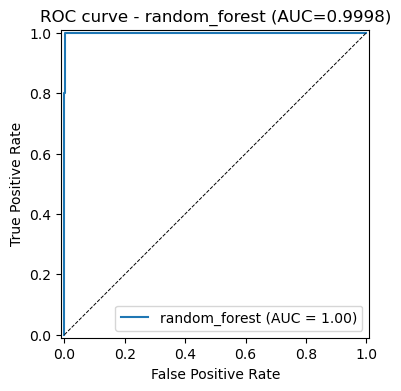


=== Evaluating: xgboost ===
Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1215
           1     1.0000    1.0000    1.0000         5

    accuracy                         1.0000      1220
   macro avg     1.0000    1.0000    1.0000      1220
weighted avg     1.0000    1.0000    1.0000      1220



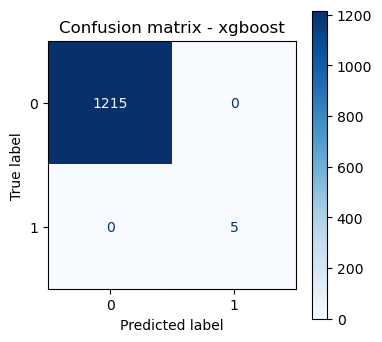

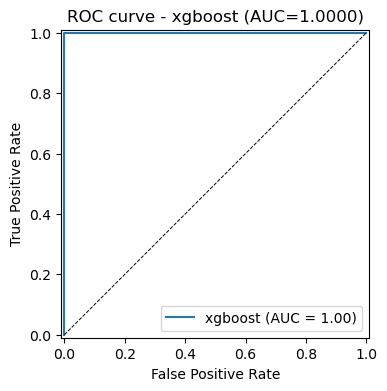

,accuracy,precision,recall,f1,roc_auc,n_test
model,,,,,,
random_forest,0.995902,0.0,0.0,0.0,0.999835,1220
xgboost,1.000000,1.0,1.0,1.0,1.000000,1220


Saved results/metrics_summary.csv


In [56]:
results = []
models_dict = {}

# first try trained_models, then pipelines, then load from files
if 'trained_models' in globals():
    models_dict.update(trained_models)

if 'pipelines' in globals():
    # pipelines may be unfitted; only evaluate fitted ones
    for k, v in pipelines.items():
        try:
            _ = v.predict(X_test[:1])
            models_dict[k] = v
        except Exception:
            pass

# finally try loading saved files as fallback
if not models_dict:
    if os.path.exists("models"):
        for fn in os.listdir("models"):
            if fn.endswith(".pkl") or fn.endswith(".joblib"):
                key = os.path.splitext(fn)[0]
                try:
                    models_dict[key] = joblib.load(os.path.join("models", fn))
                except Exception as e:
                    print("Could not load", fn, e)

print("Models to evaluate:", list(models_dict.keys()))

for name, model in models_dict.items():
    try:
        m = evaluate_model(name, model, X_test, y_test, save_plots=True)
        results.append(m)
    except Exception as e:
        print(f"Error evaluating {name}:", e)

if results:
    df_res = pd.DataFrame(results).set_index("model")
    df_res.to_csv("results/metrics_summary.csv")
    display(df_res)
    print("Saved results/metrics_summary.csv")
else:
    print("No results produced.")

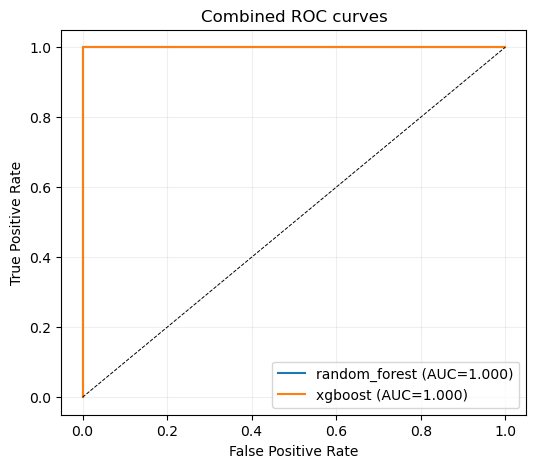

In [57]:
# Cell 4 - combined ROC (if multiple models produced scores)
plt.figure(figsize=(6,5))
plotted = 0
for name, model in models_dict.items():
    # try to get scores
    try:
        try:
            score = model.predict_proba(X_test)[:,1]
        except Exception:
            score = model.decision_function(X_test)
            if getattr(score, "ndim", 1) > 1:
                score = score[:,1]
        if score is None or len(np.unique(y_test))<2:
            continue
        fpr, tpr, _ = roc_curve(y_test, score)
        auc = roc_auc_score(y_test, score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        plotted += 1
    except Exception:
        continue

if plotted == 0:
    print("No models with valid scores to combine in ROC.")
else:
    plt.plot([0,1],[0,1],"k--", linewidth=0.7)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Combined ROC curves")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.savefig("results/combined_roc.png", bbox_inches="tight", dpi=150)
    plt.show()

In [58]:
# Cell 1: imports and shared setup
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import time

# make sure models folder exists
os.makedirs("models", exist_ok=True)

# reproducibility
RANDOM_STATE = 42

# CV splitter
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [59]:
# Cell 2: compute class imbalance (scale_pos_weight)
pos = int(y_train.eq(1).sum())
neg = int(y_train.eq(0).sum())
scale_pos_weight = neg / (pos + 1e-9)
print("Train pos/neg:", pos, "/", neg, "scale_pos_weight:", round(scale_pos_weight, 2))

Train pos/neg: 22 / 4858 scale_pos_weight: 220.82


In [60]:
# Cell 3: RandomizedSearch for RandomForest
from sklearn.ensemble import RandomForestClassifier

rf_pipe = pipelines['random_forest']  # should be Pipeline(preprocessor, RandomForestClassifier(...))

# Parameter distribution (reasonable ranges)
rf_param_dist = {
    'clf__n_estimators': [100, 200, 400, 800],
    'clf__max_depth': [None, 6, 10, 20, 40],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', 0.5]
}

rs_rf = RandomizedSearchCV(
    rf_pipe,
    rf_param_dist,
    n_iter=40,               # tune this based on time (40 is usually ok)
    scoring='f1',            # pick metric to optimize (f1 recommended for imbalanced)
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

t0 = time.time()
rs_rf.fit(X_train, y_train)
print("RandomForest RandomizedSearch done in %.1f s" % (time.time() - t0))
print("Best params:", rs_rf.best_params_)
print("Best CV f1:", rs_rf.best_score_)

# save best estimator
joblib.dump(rs_rf.best_estimator_, "models/random_forest_best.joblib", compress=3)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomForest RandomizedSearch done in 48.0 s
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}
Best CV f1: 0.9142857142857143


['models/random_forest_best.joblib']

In [61]:
# Cell 4: RandomizedSearch for XGBoost
# Install xgboost first if needed: !pip install xgboost
from xgboost import XGBClassifier

xgb_pipe = pipelines['xgboost']  # Pipeline(preprocessor, XGBClassifier(...))

xgb_param_dist = {
    'clf__n_estimators': [50, 100, 200, 400],
    'clf__max_depth': [3, 5, 7, 10],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.5, 0.7, 1.0],
    # optionally: 'clf__scale_pos_weight': [scale_pos_weight] but we set it in the pipeline constructor earlier
}

rs_xgb = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

t0 = time.time()
rs_xgb.fit(X_train, y_train)
print("XGBoost RandomizedSearch done in %.1f s" % (time.time() - t0))
print("Best params:", rs_xgb.best_params_)
print("Best CV f1:", rs_xgb.best_score_)

joblib.dump(rs_xgb.best_estimator_, "models/xgboost_best.joblib", compress=3)



Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\shish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:25:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost RandomizedSearch done in 13.2 s
Best params: {'clf__subsample': 0.8, 'clf__n_estimators': 400, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.7}
Best CV f1: 0.9310245310245311


['models/xgboost_best.joblib']

In [62]:
# Cell 5: Evaluate best models on test set
import joblib
def evaluate_on_test(model, X_test, y_test, name="model"):
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except Exception:
        y_proba = None
    print("=== Evaluation:", name, "===\n")
    print(classification_report(y_test, y_pred, digits=4))
    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", pd.crosstab(y_test, y_pred, rownames=['true'], colnames=['pred']))

# load saved best models if needed
rf_best = joblib.load("models/random_forest_best.joblib")
xgb_best = joblib.load("models/xgboost_best.joblib")

evaluate_on_test(rf_best, X_test, y_test, "RandomForest (best)")
evaluate_on_test(xgb_best, X_test, y_test, "XGBoost (best)")

=== Evaluation: RandomForest (best) ===

              precision    recall  f1-score   support

           0     1.0000    0.9992    0.9996      1215
           1     0.8333    1.0000    0.9091         5

    accuracy                         0.9992      1220
   macro avg     0.9167    0.9996    0.9543      1220
weighted avg     0.9993    0.9992    0.9992      1220

ROC-AUC: 0.999835390946502
Confusion Matrix:
 pred     0  1
true         
0     1214  1
1        0  5
=== Evaluation: XGBoost (best) ===

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1215
           1     1.0000    1.0000    1.0000         5

    accuracy                         1.0000      1220
   macro avg     1.0000    1.0000    1.0000      1220
weighted avg     1.0000    1.0000    1.0000      1220

ROC-AUC: 1.0
Confusion Matrix:
 pred     0  1
true         
0     1215  0
1        0  5


In [63]:
# Cell 6: small GridSearch around best params (optional, slower)
from sklearn.model_selection import GridSearchCV

# Example: refine rf around best params found earlier (replace keys with your rs_rf.best_params_)
rf_refine_grid = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [6, 10, 15],
    'clf__min_samples_leaf': [1,2]
}

gs_rf = GridSearchCV(
    rs_rf.best_estimator_,  # pipeline with RF
    rf_refine_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

gs_rf.fit(X_train, y_train)
print("Grid refined best:", gs_rf.best_params_, gs_rf.best_score_)
joblib.dump(gs_rf.best_estimator_, "models/random_forest_refined.joblib", compress=3)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Grid refined best: {'clf__max_depth': 6, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200} 0.9142857142857143


['models/random_forest_refined.joblib']

In [64]:
# Cell 1: imports & helper functions
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

plt.rcParams["figure.figsize"] = (6, 4)

def get_score_probs(model, X):
    """
    Return (y_pred, y_score_for_roc)
    - y_score_for_roc: model.predict_proba(X)[:,1] or model.decision_function(X)
    """
    y_pred = model.predict(X)
    # try predict_proba
    y_score = None
    try:
        y_score = model.predict_proba(X)[:, 1]
    except Exception:
        try:
            y_score = model.decision_function(X)
        except Exception:
            y_score = None
    return y_pred, y_score

def evaluate_model_on_dataset(model, X, y, pos_label=1):
    y_pred, y_score = get_score_probs(model, X)
    res = {}
    res['accuracy'] = accuracy_score(y, y_pred)
    res['precision'] = precision_score(y, y_pred, zero_division=0)
    res['recall'] = recall_score(y, y_pred, zero_division=0)
    res['f1'] = f1_score(y, y_pred, zero_division=0)
    # ROC-AUC only when score exists and there are at least two classes in y
    try:
        if y_score is not None and len(np.unique(y)) > 1:
            res['roc_auc'] = roc_auc_score(y, y_score)
        else:
            res['roc_auc'] = np.nan
    except Exception:
        res['roc_auc'] = np.nan
    return res, y_pred, y_score

def plot_confusion_and_roc(y_true, y_pred, y_score, title="Model"):
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"{title}\nConfusion matrix")
    plt.colorbar()
    ticks = [0,1]
    plt.xticks(ticks, ticks)
    plt.yticks(ticks, ticks)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="red")

    # ROC curve
    plt.subplot(1,2,2)
    if y_score is not None and len(np.unique(y_true)) > 1:
        from sklearn.metrics import roc_curve, auc
        try:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_val = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
            plt.plot([0,1],[0,1],'k--')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title('ROC curve')
            plt.legend(loc='lower right')
        except Exception:
            plt.text(0.5, 0.5, "ROC not available", ha='center')
    else:
        plt.text(0.5, 0.5, "ROC not available", ha='center')

    plt.tight_layout()
    plt.show()

In [65]:
# Cell 2: load models into a dict
models_dict = {}

# First: if you have pipelines or trained models stored in variable 'pipelines' or 'trained_models', prefer them
if 'trained_models' in globals():
    models_dict.update(trained_models)   # if you earlier stored trained models here
if 'pipelines' in globals():
    # pipelines might contain pipelines even if not fitted
    for k,v in pipelines.items():
        try:
            # quick check: model can predict
            _ = v.predict(X_test[:1])
            models_dict[k] = v
        except Exception:
            pass

# Fallback: load joblib files from models/ directory
model_dir = "models"
if os.path.exists(model_dir):
    for fname in os.listdir(model_dir):
        if fname.endswith((".joblib", ".pkl")):
            key = os.path.splitext(fname)[0]
            if key in models_dict:
                continue
            try:
                models_dict[key] = joblib.load(os.path.join(model_dir, fname))
                print(f"Loaded {fname} -> key '{key}'")
            except Exception as e:
                print("Could not load", fname, e)

print("Models available for evaluation:", list(models_dict.keys()))

Loaded RandomForest_pipeline.joblib -> key 'RandomForest_pipeline'
Loaded random_forest_best.joblib -> key 'random_forest_best'
Loaded random_forest_refined.joblib -> key 'random_forest_refined'
Loaded xgboost_best.joblib -> key 'xgboost_best'
Loaded XGBoost_final.joblib -> key 'XGBoost_final'
Loaded XGBoost_pipeline.joblib -> key 'XGBoost_pipeline'
Models available for evaluation: ['random_forest', 'xgboost', 'RandomForest_pipeline', 'random_forest_best', 'random_forest_refined', 'xgboost_best', 'XGBoost_final', 'XGBoost_pipeline']


In [67]:
# Cell 3: evaluate all models and build a results dataframe
results = []
for name, model in models_dict.items():
    print("Evaluating:", name)
    # test
    test_metrics, y_test_pred, y_test_score = evaluate_model_on_dataset(model, X_test, y_test)
    # train
    train_metrics, y_train_pred, y_train_score = evaluate_model_on_dataset(model, X_train, y_train)

    row = {
        'model': name,
        'test_accuracy': test_metrics['accuracy'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'test_roc_auc': test_metrics.get('roc_auc', np.nan),
        'train_accuracy': train_metrics['accuracy'],
        'train_f1': train_metrics['f1'],
        'train_recall': train_metrics['recall'],
        'train_roc_auc': train_metrics.get('roc_auc', np.nan)
    }
    # overfit measure
    row['f1_diff_train_minus_test'] = train_metrics['f1'] - test_metrics['f1']
    results.append(row)

df_results = pd.DataFrame(results).set_index('model')
df_results = df_results.sort_values(by=['test_f1', 'test_recall'], ascending=[False, False])
display(df_results)
# save summary
df_results.to_csv("results/metrics_summary.csv", index=True)
print("Saved results/metrics_summary.csv")


Evaluating: random_forest
Evaluating: xgboost
Evaluating: RandomForest_pipeline
Evaluating: random_forest_best
Evaluating: random_forest_refined
Evaluating: xgboost_best
Evaluating: XGBoost_final
Evaluating: XGBoost_pipeline


,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,train_accuracy,train_f1,train_recall,train_roc_auc,f1_diff_train_minus_test
model,,,,,,,,,,
xgboost,1.000000,1.000000,1.0,1.000000,1.000000,0.999795,0.977778,1.0,1.0,-0.022222
xgboost_best,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.000000
XGBoost_final,1.000000,1.000000,1.0,1.000000,1.000000,0.999795,0.977778,1.0,1.0,-0.022222
XGBoost_pipeline,1.000000,1.000000,1.0,1.000000,1.000000,0.999795,0.977778,1.0,1.0,-0.022222
random_forest_best,0.999180,0.833333,1.0,0.909091,0.999835,1.000000,1.000000,1.0,1.0,0.090909
random_forest_refined,0.999180,0.833333,1.0,0.909091,0.999835,1.000000,1.000000,1.0,1.0,0.090909
random_forest,0.995902,0.000000,0.0,0.000000,0.999835,1.000000,1.000000,1.0,1.0,1.000000
RandomForest_pipeline,0.995902,0.000000,0.0,0.000000,0.999835,1.000000,1.000000,1.0,1.0,1.000000


Saved results/metrics_summary.csv



--- xgboost ---
Test metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}

Classification report (test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      1.00      1.00         5

    accuracy                           1.00      1220
   macro avg       1.00      1.00      1.00      1220
weighted avg       1.00      1.00      1.00      1220



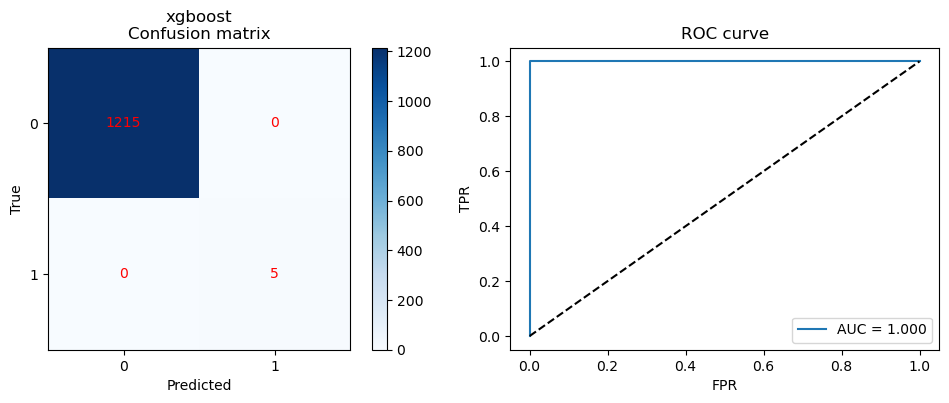


--- xgboost_best ---
Test metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}

Classification report (test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1215
           1       1.00      1.00      1.00         5

    accuracy                           1.00      1220
   macro avg       1.00      1.00      1.00      1220
weighted avg       1.00      1.00      1.00      1220



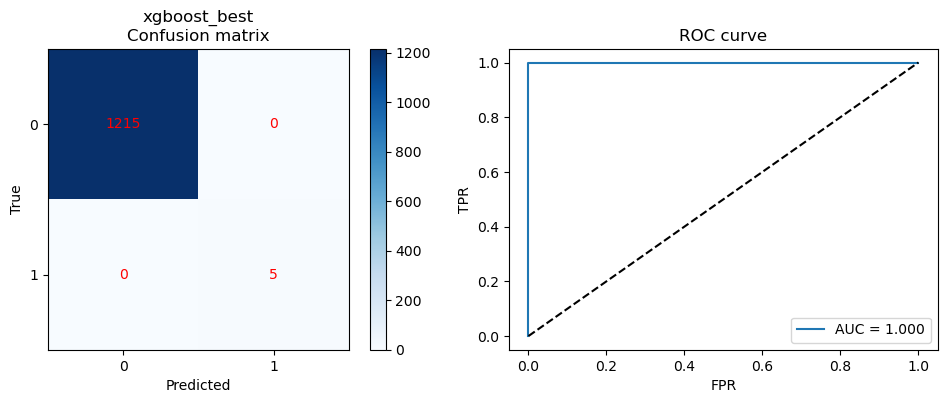

In [68]:
# Cell 4: Show detailed plots for top candidates
top_n = min(2, len(df_results))
if top_n == 0:
    print("No models available.")
else:
    top_models = df_results.index.tolist()[:top_n]
    for name in top_models:
        print("\n---", name, "---")
        model = models_dict[name]
        test_metrics, y_test_pred, y_test_score = evaluate_model_on_dataset(model, X_test, y_test)
        print("Test metrics:", test_metrics)
        # classification report
        print("\nClassification report (test):\n", classification_report(y_test, y_test_pred, zero_division=0))
        plot_confusion_and_roc(y_test, y_test_pred, y_test_score, title=name)

In [69]:
# Cell 5: Select best model using criteria: highest test_f1, tiebreaker = test_recall.
# Also flag models with large train-test f1 gap (overfitting).
if df_results.shape[0] == 0:
    raise RuntimeError("No evaluated models to select from.")

# pick best by test_f1 then test_recall
df_sorted = df_results.copy()
best_name = df_sorted.sort_values(['test_f1','test_recall'], ascending=[False, False]).index[0]
best_row = df_sorted.loc[best_name]

# Overfitting check: if train_f1 - test_f1 > 0.10 mark as potential overfit
overfit_threshold = 0.10
overfit_flag = best_row['f1_diff_train_minus_test'] > overfit_threshold

print("Selected best model:", best_name)
print(best_row.to_dict())
if overfit_flag:
    print(f"WARNING: Model {best_name} shows a train-test F1 gap of {best_row['f1_diff_train_minus_test']:.3f} (> {overfit_threshold}). Might be overfitting.")
else:
    print("No significant overfitting detected for the chosen model.")

# If you'd prefer to force recall over f1, you can change selection logic here.

Selected best model: xgboost
{'test_accuracy': 1.0, 'test_precision': 1.0, 'test_recall': 1.0, 'test_f1': 1.0, 'test_roc_auc': 1.0, 'train_accuracy': 0.9997950819672131, 'train_f1': 0.9777777777777777, 'train_recall': 1.0, 'train_roc_auc': 1.0, 'f1_diff_train_minus_test': -0.022222222222222254}
No significant overfitting detected for the chosen model.


In [70]:
# Cell 6: Save final model & short justification
final_dir = "models"
os.makedirs(final_dir, exist_ok=True)

selected_model_name = best_name
final_model = models_dict[selected_model_name]
final_path = os.path.join(final_dir, "final_model.joblib")
joblib.dump(final_model, final_path, compress=3)
print("Saved final model to:", final_path)

# write justification
justification = f"""Selected model: {selected_model_name}
Selection criteria: highest test F1 (primary) with test Recall as tiebreaker.
Test metrics:
{best_row.to_dict()}

Overfitting flag: {overfit_flag}
Notes: If overfitting flagged, consider additional regularization, tuning, or more data.
"""
with open(os.path.join(final_dir, "final_model_selection.txt"), "w") as f:
    f.write(justification)
print("Saved selection justification to:", os.path.join(final_dir, "final_model_selection.txt"))

Saved final model to: models\final_model.joblib
Saved selection justification to: models\final_model_selection.txt


In [72]:
# Cell A: imports & configuration
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Output file
OUT_PATH = os.path.join("data", "processed", "habitability_ranked.csv")

# Candidate dataset paths (in order)
CANDIDATE_DATA = [
    os.path.join("data","processed","exohabit_ml.csv"),
    os.path.join("data","processed","preprocessed.csv"),
    os.path.join("data","preprocessed","preprocessed.csv"),
    os.path.join("data","preprocessed","preprocessed (2).csv"),
    os.path.join("data","preprocessed","preprocessed (2).xlsx")  # won't auto read but kept
]

# Candidate model filenames (look in models/)
MODEL_CANDIDATES = [
    os.path.join("models","final_model.joblib"),
    os.path.join("models","final_model.pkl"),
    os.path.join("models","random_forest_best.joblib"),
    os.path.join("models","xgboost_best.joblib"),
    os.path.join("models","rf_pipeline.joblib"),
    os.path.join("models","rf_pipeline.pkl"),
]

In [73]:
# Cell B: load a model
def find_model():
    # 1) try explicit candidates
    for p in MODEL_CANDIDATES:
        if os.path.exists(p):
            return p
    # 2) fallback: find any .joblib/.pkl under models/
    if os.path.exists("models"):
        for f in os.listdir("models"):
            if f.lower().endswith((".joblib", ".pkl")):
                return os.path.join("models", f)
    return None

model_path = find_model()
if not model_path:
    raise FileNotFoundError("No model file found in models/ (looked for final_model or any .joblib/.pkl).")

print("Loading model from:", model_path)
model = joblib.load(model_path)
print("Loaded model type:", type(model))

Loading model from: models\final_model.joblib
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


In [74]:
# Cell C: load dataset (try list of common file locations)
data_path = None
for p in CANDIDATE_DATA:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    # fallback: if you already have a DataFrame in memory named df or X_full, use it
    if 'df' in globals():
        df_full = df.copy()
        print("Using in-memory df.")
    else:
        raise FileNotFoundError(f"No processed dataset found. Checked: {CANDIDATE_DATA}")

else:
    # load CSV (if xlsx you'll need pd.read_excel)
    if data_path.lower().endswith(".csv"):
        df_full = pd.read_csv(data_path)
    else:
        # try csv fallback
        try:
            df_full = pd.read_csv(data_path)
        except Exception as e:
            raise RuntimeError(f"Can't read dataset at {data_path}: {e}")

    print("Loaded dataset:", data_path, "shape:", df_full.shape)

# Identify identifier column candidates and target column
id_candidates = ['planet_name','pl_name','name','planet','planet_id','pl_hostname','host_star_name']
id_col = next((c for c in id_candidates if c in df_full.columns), None)

target_candidates = ['habitable_binary','habitable','target','is_habitable']
target_col = next((c for c in target_candidates if c in df_full.columns), None)

print("Identified id_col:", id_col, "target_col:", target_col)

Using in-memory df.
Identified id_col: planet_name target_col: habitable_binary


In [75]:
# Cell D: compute score and save ranking
# Build feature DataFrame X_for_model: drop only id and target (let pipeline handle column selection)
drop_cols = []
if id_col:
    drop_cols.append(id_col)
if target_col:
    drop_cols.append(target_col)

X_for_model = df_full.drop(columns=[c for c in drop_cols if c in df_full.columns])

# compute probabilities or decision scores
def compute_probabilities(model, X):
    # Attempt predict_proba
    try:
        probs = model.predict_proba(X)
        # If multiclass, assume positive class is last column; we want probability of positive class (1)
        if probs.ndim == 2 and probs.shape[1] >= 2:
            pos_prob = probs[:, -1]
        else:
            pos_prob = probs.ravel()
        return pos_prob
    except Exception:
        # try decision_function then scale to 0-1
        try:
            scores = model.decision_function(X)
            # make 2D
            scores = np.asarray(scores).ravel().reshape(-1,1)
            scaler = MinMaxScaler(feature_range=(0,1))
            scaled = scaler.fit_transform(scores).ravel()
            return scaled
        except Exception:
            # last resort: model.predict (0/1) as probability
            try:
                preds = model.predict(X)
                return preds.astype(float)
            except Exception as e:
                raise RuntimeError(f"Model cannot produce probabilities or decision scores: {e}")

print("Computing habitability probabilities. This may take a bit...")
probs = compute_probabilities(model, X_for_model)
print("Computed probabilities shape:", probs.shape)

# Add to DataFrame
out_df = df_full.copy()
out_df['_habitability_prob'] = probs
# predicted class using 0.5 threshold (you can change threshold later)
out_df['_predicted_habitable'] = (out_df['_habitability_prob'] >= 0.5).astype(int)

# ranking
out_df['_habitability_rank'] = out_df['_habitability_prob'].rank(method='first', ascending=False).astype(int)
out_df = out_df.sort_values('_habitability_prob', ascending=False).reset_index(drop=True)

# keep helpful columns: id_col, host star maybe, probability, predicted, rank, plus some key features if exist
keep_cols = []
if id_col: keep_cols.append(id_col)
if 'host_star_name' in out_df.columns: keep_cols.append('host_star_name')
keep_cols += ['_habitability_prob','_predicted_habitable','_habitability_rank']

# also include user-defined habitability_score if present
if 'habitat_score' in out_df.columns:
    keep_cols.append('habitat_score')
if 'habitable_binary' in out_df.columns:
    keep_cols.append('habitable_binary')

# ensure columns present
keep_cols = [c for c in keep_cols if c in out_df.columns]
ranked_df = out_df[keep_cols].copy()

# create output directory and save
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
ranked_df.to_csv(OUT_PATH, index=False)
print("Saved habitability ranking to:", OUT_PATH)
print("\nTop 10 ranked planets:")
display(ranked_df.head(10))

Computing habitability probabilities. This may take a bit...
Computed probabilities shape: (6100,)
Saved habitability ranking to: data\processed\habitability_ranked.csv

Top 10 ranked planets:


,planet_name,host_star_name,_habitability_prob,_predicted_habitable,_habitability_rank,habitable_binary
0,Kepler-395 c,Kepler-395,0.999993,1,1,1
1,TOI-2095 c,TOI-2095,0.999993,1,2,1
2,Kepler-1649 c,Kepler-1649,0.999986,1,3,1
3,Kepler-437 b,Kepler-437,0.999979,1,4,1
4,K2-3 d,K2-3,0.999969,1,5,1
5,TOI-700 e,TOI-700,0.999958,1,6,1
6,Kepler-296 e,Kepler-296,0.999954,1,7,1
7,K2-9 b,K2-9,0.999949,1,8,1
8,Kepler-186 e,Kepler-186,0.999941,1,9,1
9,LP 890-9 c,LP 890-9,0.999936,1,10,1


In [1]:
import joblib

model = joblib.load("models/final_model.joblib")

In [2]:
model = joblib.load("models/random_forest_best.joblib")

In [4]:
feature_names = model.named_steps["pre"].get_feature_names_out()

In [5]:
import pandas as pd

importance = model.named_steps["clf"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
11,num__habitability_score,0.493471
18,num__eq_temp_k_scaled,0.214592
6,num__eq_temp_k,0.197095
14,num__radius_earth_scaled,0.027430
1,num__pl_radj,0.025198
8,num__star_temp_k,0.016754
0,num__radius_earth,0.016172
20,num__star_temp_k_scaled,0.004562
16,num__orbital_period_scaled,0.003296
17,num__semimajor_axis_scaled,0.000960


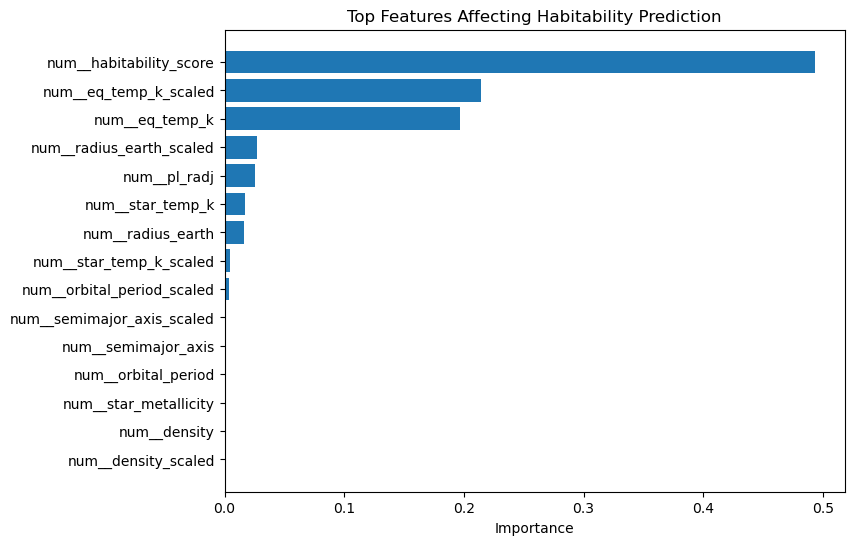

In [6]:
import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance["feature"][:top_n][::-1],
    feature_importance["importance"][:top_n][::-1]
)

plt.xlabel("Importance")
plt.title("Top Features Affecting Habitability Prediction")
plt.show()

In [7]:
print("Top 10 Important Features:\n")
print(feature_importance.head(10))

Top 10 Important Features:

                       feature  importance
11     num__habitability_score    0.493471
18       num__eq_temp_k_scaled    0.214592
6               num__eq_temp_k    0.197095
14    num__radius_earth_scaled    0.027430
1                 num__pl_radj    0.025198
8             num__star_temp_k    0.016754
0            num__radius_earth    0.016172
20     num__star_temp_k_scaled    0.004562
16  num__orbital_period_scaled    0.003296
17  num__semimajor_axis_scaled    0.000960


In [9]:
import joblib

xgb_best = joblib.load("models/xgboost_best.joblib")
joblib.dump(xgb_best, "models/final_model.pkl")

['models/final_model.pkl']

In [10]:
import os
os.listdir("models")

['final_model.joblib',
 'final_model.pkl',
 'final_model_selection.txt',
 'RandomForest_pipeline.joblib',
 'random_forest.pkl',
 'random_forest_best.joblib',
 'random_forest_refined.joblib',
 'xgboost.pkl',
 'xgboost_best.joblib',
 'XGBoost_final.joblib',
 'XGBoost_pipeline.joblib']

In [32]:
import pickle

with open("../models/final_model.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'numpy.ndarray'>


In [16]:
import joblib

model = joblib.load("../models/final_model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [17]:
import pandas as pd

df = pd.read_csv("../data/processed/preprocessed.csv")

In [20]:
X = df.drop(columns=["habitable_binary"])

In [19]:
print(df.columns)

Index(['planet_name', 'host_star_name', 'radius_earth', 'pl_radj',
       'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis',
       'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity',
       'star_metallicity', 'star_spectype', 'habitability_score',
       'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B',
       'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown',
       'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled',
       'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled',
       'star_temp_k_scaled', 'star_luminosity_scaled',
       'star_metallicity_scaled', 'habitable_binary'],
      dtype='object')


In [21]:
df["habitability_probability"] = model.predict_proba(X)[:,1]

In [22]:
df = df.sort_values("habitability_probability", ascending=False)

df["habitability_rank"] = range(1, len(df) + 1)

In [23]:
df.to_csv("../data/processed/habitability_ranked.csv", index=False)

In [31]:
# keep only important columns
final_output = df[
[
"planet_name",
"host_star_name",
"habitability_probability",
"habitability_rank",
"habitable_binary"
]
]

# save to required location
final_output.to_csv("../data/processed/habitability_ranked.csv", index=False)

print("Saved clean habitability ranking file.")

Saved clean habitability ranking file.


In [28]:
print(df.columns)

Index(['planet_name', 'host_star_name', 'radius_earth', 'pl_radj',
       'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis',
       'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity',
       'star_metallicity', 'star_spectype', 'habitability_score',
       'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B',
       'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown',
       'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled',
       'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled',
       'star_temp_k_scaled', 'star_luminosity_scaled',
       'star_metallicity_scaled', 'habitable_binary',
       'habitability_probability', 'habitability_rank'],
      dtype='object')


In [33]:
df.head()

,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary,habitability_probability,habitability_rank
4008,Kepler-395 c,Kepler-395,1.250,0.111518,196.050555,NaN,34.989447,0.1561,264.0,1.33,...,0.782645,0.261444,-1.549575,0.0,-2.014766,0.00000,-2.285714,1,0.999987,1
5377,TOI-2095 c,TOI-2095,1.330,0.118655,7.400000,0.023283,28.172320,0.1370,297.0,1.33,...,0.559427,0.165965,-1.456091,0.0,-1.988515,-1.43205,-1.047619,1,0.999973,2
1687,K2-3 d,K2-3,1.458,0.130074,2.200000,0.006922,44.556030,0.2014,305.2,1.33,...,1.095891,0.487896,-1.432861,0.0,-1.895543,-1.20449,-0.652381,1,0.999963,3
4089,Kepler-437 b,Kepler-437,1.370,0.122223,196.050555,NaN,66.650548,0.2737,294.0,1.33,...,1.819348,0.849320,-1.464589,0.0,-1.257862,0.00000,-1.428571,1,0.999961,4
2990,Kepler-1649 c,Kepler-1649,1.060,0.094567,196.050555,NaN,19.535270,0.1038,234.0,1.33,...,0.276617,0.000000,-1.634561,0.0,-2.556194,-2.26048,-0.619048,1,0.999958,5


In [35]:
df = pd.read_csv("../data/processed/preprocessed.csv")

In [36]:
df.to_csv("../data/processed/final_model.csv", index=False)

In [37]:
# Cell 1: imports and paths
import os
import joblib
import pickle
import pandas as pd
import numpy as np

ROOT = ".."                # adjust if your notebook root differs
DATA_PROCESSED_DIR = os.path.join(ROOT, "data", "processed")
MODEL_CANDIDATES = [
    os.path.join(ROOT, "models", "final_model.pkl"),
    os.path.join(ROOT, "models", "final_model.joblib"),
    os.path.join(ROOT, "models", "xgboost_best.joblib"),
    os.path.join(ROOT, "models", "random_forest_best.joblib"),
    # fallback where you accidentally stored models
    os.path.join(ROOT, "notebooks", "models", "final_model.pkl"),
    os.path.join(ROOT, "notebooks", "models", "final_model.joblib"),
    os.path.join(ROOT, "notebooks", "models", "xgboost_best.joblib"),
]
DATA_INPUT_PATHS = [
    os.path.join(ROOT, "data", "processed", "preprocessed.csv"),
    os.path.join(ROOT, "data", "processed", "exohabit_ml.csv"),
    os.path.join(ROOT, "data", "processed", "preprocessed (2).csv"),
]

print("Will look for model in:", MODEL_CANDIDATES)
print("Will look for processed data in:", DATA_INPUT_PATHS)

Will look for model in: ['..\\models\\final_model.pkl', '..\\models\\final_model.joblib', '..\\models\\xgboost_best.joblib', '..\\models\\random_forest_best.joblib', '..\\notebooks\\models\\final_model.pkl', '..\\notebooks\\models\\final_model.joblib', '..\\notebooks\\models\\xgboost_best.joblib']
Will look for processed data in: ['..\\data\\processed\\preprocessed.csv', '..\\data\\processed\\exohabit_ml.csv', '..\\data\\processed\\preprocessed (2).csv']


In [38]:
# Cell 2: load the preprocessed dataframe
df = None
for p in DATA_INPUT_PATHS:
    if os.path.exists(p):
        print("Loading data from:", p)
        df = pd.read_csv(p)
        break

if df is None:
    raise FileNotFoundError("Could not find a preprocessed CSV. Put it in data/processed/ and retry.")

print("Data shape:", df.shape)
print("Columns:", list(df.columns)[:40])

Loading data from: ..\data\processed\preprocessed.csv
Data shape: (6100, 34)
Columns: ['planet_name', 'host_star_name', 'radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled', 'habitable_binary']


In [39]:
# Cell 3: attempt to load a saved model (tries several paths)
model = None
used_model_path = None
for mp in MODEL_CANDIDATES:
    if os.path.exists(mp):
        try:
            print("Trying to load model:", mp)
            # try joblib first (works for sklearn pipelines and models)
            model = joblib.load(mp)
            used_model_path = mp
            break
        except Exception as e_job:
            try:
                # try pickle
                with open(mp, "rb") as f:
                    model = pickle.load(f)
                used_model_path = mp
                break
            except Exception as e_pickle:
                print("Failed to load", mp, "joblib error:", e_job, "pickle error:", e_pickle)

if model is None:
    raise FileNotFoundError("No saved model found in candidate paths. Save the pipeline/model and try again.")

print("Loaded model from:", used_model_path)
print("Model type:", type(model))
# if pipeline, show steps (if exists)
if hasattr(model, "named_steps"):
    print("Pipeline steps:", list(model.named_steps.keys()))

Trying to load model: ..\models\final_model.pkl
Loaded model from: ..\models\final_model.pkl
Model type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['pre', 'clf']


In [40]:
# Cell 4: compute predicted probabilities and class labels
# We'll try model.predict_proba(df). If that fails, attempt model.predict_proba(X) where X is subset of columns.

# 1) Candidate feature inputs:
candidate_Xs = {
    "full_df": df,
    # common pattern: scaled features may end with '_scaled'
    "scaled_cols": df[[c for c in df.columns if c.endswith("_scaled")]] if any(c.endswith("_scaled") for c in df.columns) else None,
    # some numeric columns often present
    "numeric_candidates": df.select_dtypes(include=[np.number]) if df.select_dtypes(include=[np.number]).shape[1] > 0 else None
}

# 2) helper to try predict_proba
def try_predict_proba(m, X):
    try:
        proba = m.predict_proba(X)
        # proba shape (n_samples, n_classes) -> we want probability of class 1 (positive)
        if proba.shape[1] == 2:
            return np.asarray(proba)[:, 1]
        else:
            # if only one column then just use it
            return np.asarray(proba)[:, 0]
    except Exception as e:
        # re-raise to allow debugging, but return None in caller
        raise

# 3) attempt predictions
habitability_prob = None
last_error = None
# first try if model accepts the full dataframe
for name, Xcand in candidate_Xs.items():
    if Xcand is None:
        continue
    try:
        print("Trying predict_proba with:", name, "shape:", Xcand.shape)
        habitability_prob = try_predict_proba(model, Xcand)
        print("Success with:", name)
        used_X_name = name
        break
    except Exception as e:
        last_error = e
        print("Failed with", name, "->", e)

# If still None and model is a pipeline but the pipeline expects only raw columns, try:
if habitability_prob is None and hasattr(model, "predict_proba"):
    try:
        # final fallback: try model on df.values
        habitability_prob = try_predict_proba(model, df.values)
        used_X_name = "df.values"
        print("Success with df.values")
    except Exception as e:
        last_error = e

if habitability_prob is None:
    # Can't compute probabilities automatically
    raise RuntimeError(f"Could not call model.predict_proba automatically. Last error: {last_error}\n"
                       "If your model is an estimator (not pipeline) you must pass the exact feature columns used in training.\n"
                       "Option: save a pipeline that includes preprocessing and then call pipeline.predict_proba(df).")

# 4) create predicted label and ranking
df = df.copy()     # avoid modifying original in place
df["_habitability_prob"] = habitability_prob
df["_predicted_habitable"] = (df["_habitability_prob"] >= 0.5).astype(int)   # threshold 0.5 (change if needed)
df["_habitability_rank"] = df["_habitability_prob"].rank(ascending=False, method="first").astype(int)

print("Added columns: _habitability_prob, _predicted_habitable, _habitability_rank")
print("Sample top rows:")
display(df.sort_values("_habitability_prob", ascending=False).head(10))

Trying predict_proba with: full_df shape: (6100, 34)
Success with: full_df
Added columns: _habitability_prob, _predicted_habitable, _habitability_rank
Sample top rows:


,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary,_habitability_prob,_predicted_habitable,_habitability_rank
4008,Kepler-395 c,Kepler-395,1.250000,0.111518,196.050555,NaN,34.989447,0.15610,264.0,1.33,...,0.261444,-1.549575,0.0,-2.014766,0.00000,-2.285714,1,0.999987,1,1
5377,TOI-2095 c,TOI-2095,1.330000,0.118655,7.400000,0.023283,28.172320,0.13700,297.0,1.33,...,0.165965,-1.456091,0.0,-1.988515,-1.43205,-1.047619,1,0.999973,1,2
1687,K2-3 d,K2-3,1.458000,0.130074,2.200000,0.006922,44.556030,0.20140,305.2,1.33,...,0.487896,-1.432861,0.0,-1.895543,-1.20449,-0.652381,1,0.999963,1,3
4089,Kepler-437 b,Kepler-437,1.370000,0.122223,196.050555,NaN,66.650548,0.27370,294.0,1.33,...,0.849320,-1.464589,0.0,-1.257862,0.00000,-1.428571,1,0.999961,1,4
2990,Kepler-1649 c,Kepler-1649,1.060000,0.094567,196.050555,NaN,19.535270,0.10380,234.0,1.33,...,0.000000,-1.634561,0.0,-2.556194,-2.26048,-0.619048,1,0.999958,1,5
4877,LP 890-9 c,LP 890-9,1.367000,0.121956,25.300000,0.079603,8.457463,0.03984,272.0,1.33,...,-0.319732,-1.526912,0.0,-2.982773,-2.81447,-0.038095,1,0.999928,1,6
4095,Kepler-442 b,Kepler-442,1.560000,0.139174,196.050555,NaN,112.306839,0.39300,260.0,1.33,...,1.445693,-1.560907,0.0,-1.102543,0.00000,-1.238095,1,0.999923,1,7
2718,Kepler-1450 b,Kepler-1450,1.550000,0.138282,196.050555,NaN,54.509417,0.23920,310.0,1.33,...,0.676856,-1.419263,0.0,-1.281925,0.00000,-1.523810,1,0.999919,1,8
5741,TOI-700 e,TOI-700,0.949186,0.084681,196.050555,NaN,27.809690,0.10380,272.9,1.33,...,0.000000,-1.524363,0.0,-2.291496,0.00000,0.000000,1,0.999918,1,9
3267,Kepler-186 e,Kepler-186,1.260000,0.112410,196.050555,NaN,22.407774,0.12180,322.0,1.33,...,0.089981,-1.385269,0.0,-1.986328,0.00000,-0.904762,1,0.999898,1,10


In [42]:
import os

# 1) show where we are (helps debug ../ issues)
print("Current working directory:", os.getcwd())

# 2) directory and filename you want to write to
DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")   # adjust if your notebook root is different
out_path = os.path.join(DATA_PROCESSED_DIR, "habitability_ranked.csv")

# 3) make sure required columns exist (avoid KeyError)
keep_cols = [
    "planet_name",
    "host_star_name",
    "_habitability_prob",
    "_predicted_habitable",
    "_habitability_rank",
    "habitable_binary"
]
# keep only those that actually exist in df
keep_cols = [c for c in keep_cols if c in df.columns]
if not keep_cols:
    raise RuntimeError("None of the expected output columns exist in df. Run the ranking / prediction cells first and re-check df.columns.")

final_output = df[keep_cols].copy()
if "_habitability_rank" in final_output.columns:
    final_output = final_output.sort_values("_habitability_rank")  # top first

# 4) ensure folder exists
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
print("Writing to:", os.path.abspath(out_path))

# 5) quick writability test (gives clear error if file is locked)
try:
    # open in append mode then immediately close; doesn't truncate existing file
    with open(out_path, "a"):
        pass
except PermissionError as e:
    raise PermissionError(
        f"Permission denied: cannot open {out_path} for writing.\n"
        "Common causes:\n"
        "- The file is open in Excel/another app (close it and retry).\n"
        "- The path is on a protected/readonly location.\n"
        "- Notebook process lacks permissions. Try running as admin or choose another folder.\n"
        f"Original error: {e}"
    )

# 6) finally save
final_output.to_csv(out_path, index=False)
print("Saved habitability ranking to:", out_path)
display(final_output.head(20))

Current working directory: c:\Users\shish\Desktop\B13-ExoHabitAI\notebooks
Writing to: c:\Users\shish\Desktop\B13-ExoHabitAI\data\processed\habitability_ranked.csv


PermissionError: Permission denied: cannot open ..\data\processed\habitability_ranked.csv for writing.
Common causes:
- The file is open in Excel/another app (close it and retry).
- The path is on a protected/readonly location.
- Notebook process lacks permissions. Try running as admin or choose another folder.
Original error: [Errno 13] Permission denied: '..\\data\\processed\\habitability_ranked.csv'